In [1]:
#installing the libararies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
from statsmodels.tsa.arima.model import ARIMA


In [2]:
#load our dataset
df = pd.read_csv('../data/gas_price_2526.csv')

#display basic information
print(df.info())
#display the first 5 rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         500 non-null    object 
 1   daily price  500 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.9+ KB
None


,date,daily price
0,19/01/2025,39.85
1,20/01/2025,37.21
2,21/01/2025,37.33
3,22/01/2025,37.85
4,23/01/2025,35.70


In [3]:
# date is object(means string) convert into date and time object
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y') #(dd/mm/yyyy)

#set date column as index(TS)
df.set_index('date', inplace=True)



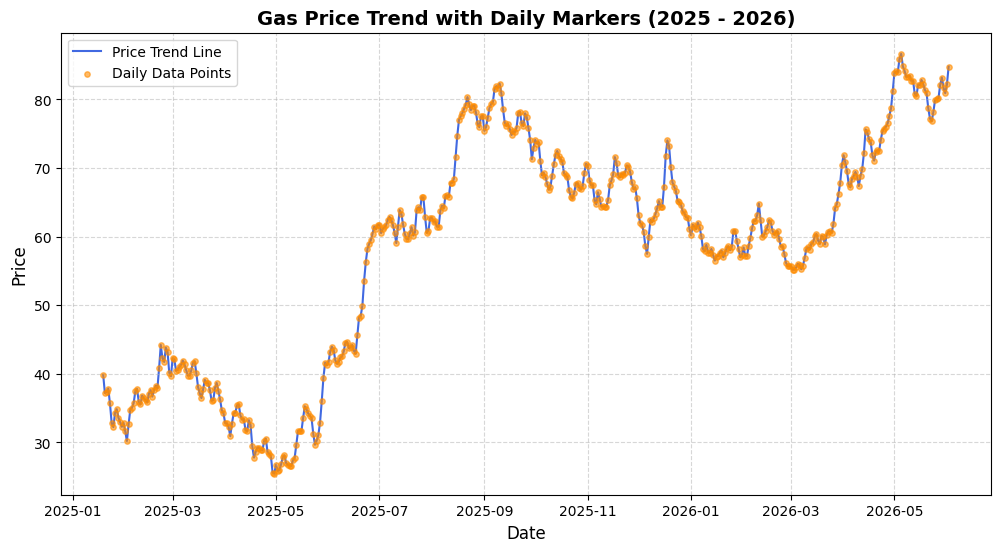

In [4]:
#line and scatter plot
plt.figure(figsize=(12, 6))

#continuous line
plt.plot(df.index, df['daily price'], color='royalblue', linewidth=1.5, label='Price Trend Line', zorder=1)
#s => size of dot, alpha=>transparency, =
plt.scatter(df.index, df['daily price'], color='darkorange', s=15, alpha=0.6, label='Daily Data Points', zorder=2)

plt.title('Gas Price Trend with Daily Markers (2025 - 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

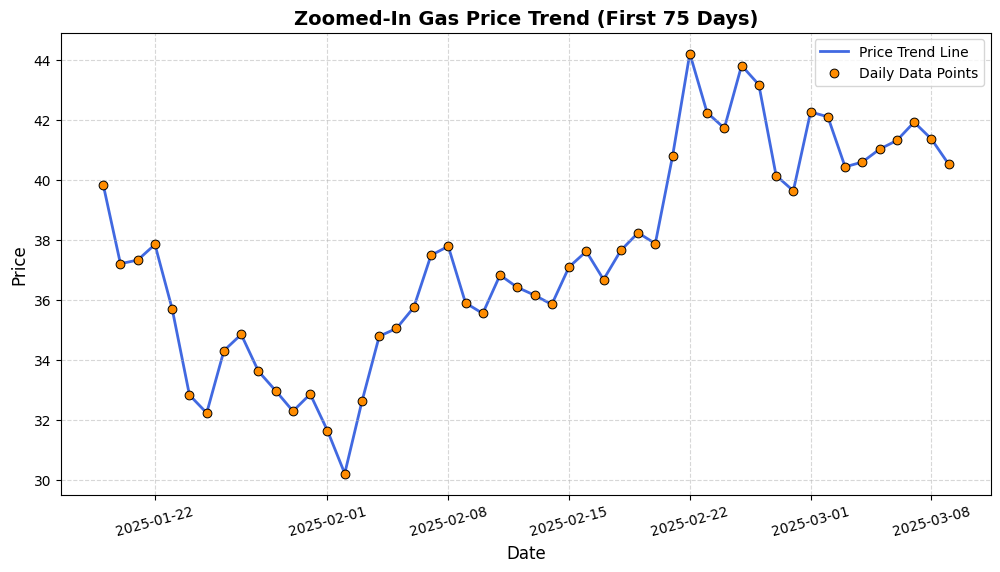

In [18]:
#too clumsy with all 500 pts, zoom for 10% 50 datapoints (first 50 data points)
df_zoom = df.iloc[0:50]

plt.figure(figsize=(12, 6))

#line for 50 pts
plt.plot(df_zoom.index, df_zoom['daily price'], color='royalblue', linewidth=2, label='Price Trend Line', zorder=1)

#add dots(scatter points/data points for the same timeframe)
plt.scatter(df_zoom.index, df_zoom['daily price'], color='darkorange', s=40, edgecolors='black', linewidth=0.7, label='Daily Data Points', zorder=2)

plt.title('Zoomed-In Gas Price Trend (First 75 Days)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xticks(rotation=15)
plt.show()

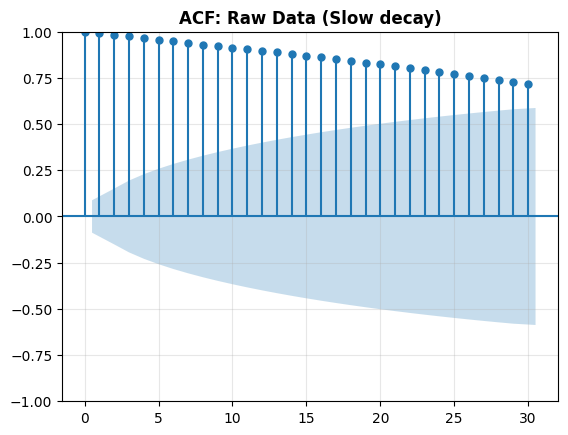

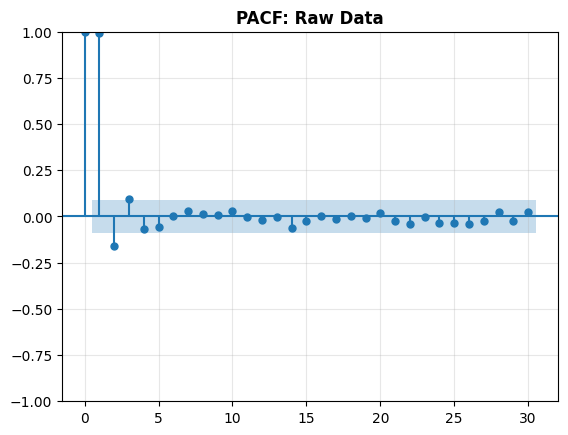

In [5]:
#checking the data for stationary
#from line graph we can see clear trend
#statioanrity checks can be done using the acf and pacf plots

#raw acf
plot_acf(df['daily price'], lags=30)
plt.title('ACF: Raw Data (Slow decay)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

#raw pacf
plot_pacf(df['daily price'], lags=30)
plt.title('PACF: Raw Data', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

clearly the data is unstationary our model arma assumes the data to be stationary, so we have to make the data stationary, we can do that by differencing the price column, we will create new column for our differenced price data

In [6]:
#creating differenced col
df['price_diff'] = df['daily price'].diff()

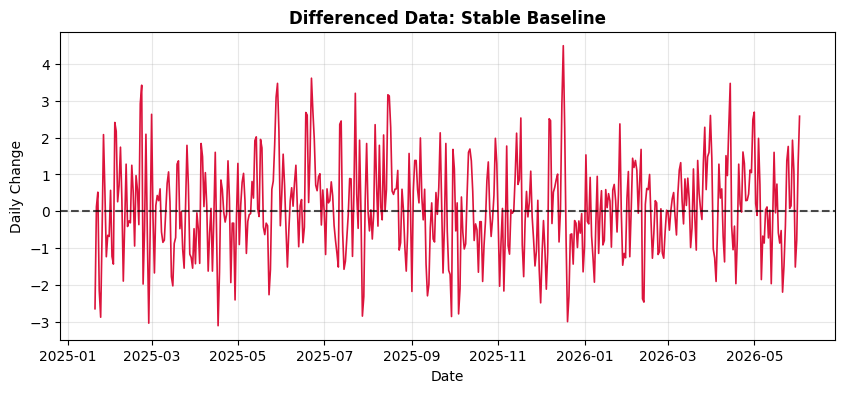

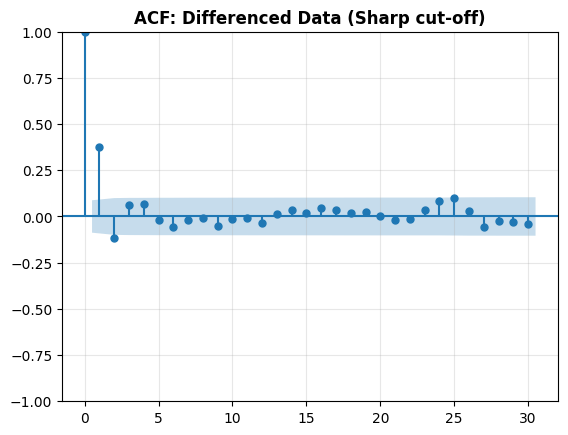

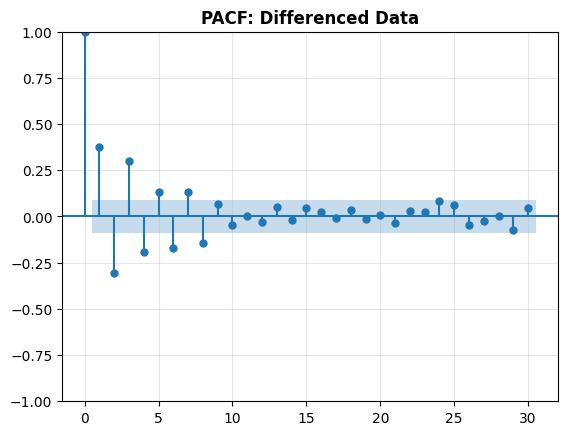

In [7]:
#differenced data lineplot

#remove nan values caused by differencing

diff_clean = df['price_diff'].dropna()

#differenced line

plt.figure(figsize=(10, 4))
plt.plot(diff_clean.index, diff_clean, color='crimson', linewidth=1.2)
plt.axhline(0, color='black', linestyle='--', alpha=0.7)  # Baseline at zero change
plt.title('Differenced Data: Stable Baseline', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Daily Change')
plt.grid(True, alpha=0.3)
plt.show()

#differenced data acf
plot_acf(diff_clean, lags=30)
plt.title('ACF: Differenced Data (Sharp cut-off)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

#differenced data pacf

plot_pacf(diff_clean, lags=30)
plt.title('PACF: Differenced Data', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

defining models, is the one we are looking at now, arma takes the stationary data, it cant perform on non stationary data, as we will be required to give it the stationary data
the parameter d will be 1 which stands for the data has been differenced once

while arima is a manual model, it can perform on raw data meaning, we can define its parameters (p,d,q) which we are required to do so and as we give the parmeters to loop on the model picks the best differenced data in our case could be 0,1,2 0 stands for raw data, mostly I am assuming model is going to pick d =2 even if we have found the stationarity at d=1(differencing one time)

In [8]:
#ARIMA implementation
warnings.filterwarnings("ignore")

#paramter ranges as per assignment
p_values = range(0, 9)  #0 to 8
d_values = range(0, 3)  #0 to 2
q_values = range(0, 9)  #0 to 8

best_aic = float("inf")
best_order = None
best_model_results = None

print('start')

#loop all possible params
for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                #fit on raw data column d is picked by the model automatically
                model = ARIMA(df['daily price'], order=(p, d, q))
                results = model.fit()
                
                current_aic = results.aic
                
                if current_aic < best_aic:
                    best_aic = current_aic
                    best_order = (p, d, q)
                    best_model_results = results
                    
            except Exception as e:
                continue

print("completed")
print(f"The Best Model Parameters are: ARIMA{best_order}")
print(f"The Lowest Achieved AIC Score is: {best_aic:.4f}")

start
completed
The Best Model Parameters are: ARIMA(1, 1, 3)
The Lowest Achieved AIC Score is: 1418.0843


my guess was wrong model picked the d =1, which is the first differenced data. which is a good sign which means the model is not overfitting on the data

                               SARIMAX Results                                
Dep. Variable:            daily price   No. Observations:                  500
Model:                 ARIMA(1, 1, 3)   Log Likelihood                -704.042
Date:                Fri, 12 Jun 2026   AIC                           1418.084
Time:                        17:31:49   BIC                           1439.147
Sample:                    01-19-2025   HQIC                          1426.350
                         - 06-02-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8231      0.077    -10.636      0.000      -0.975      -0.671
ma.L1          1.6338      0.085     19.165      0.000       1.467       1.801
ma.L2          0.4884      0.116      4.206      0.0

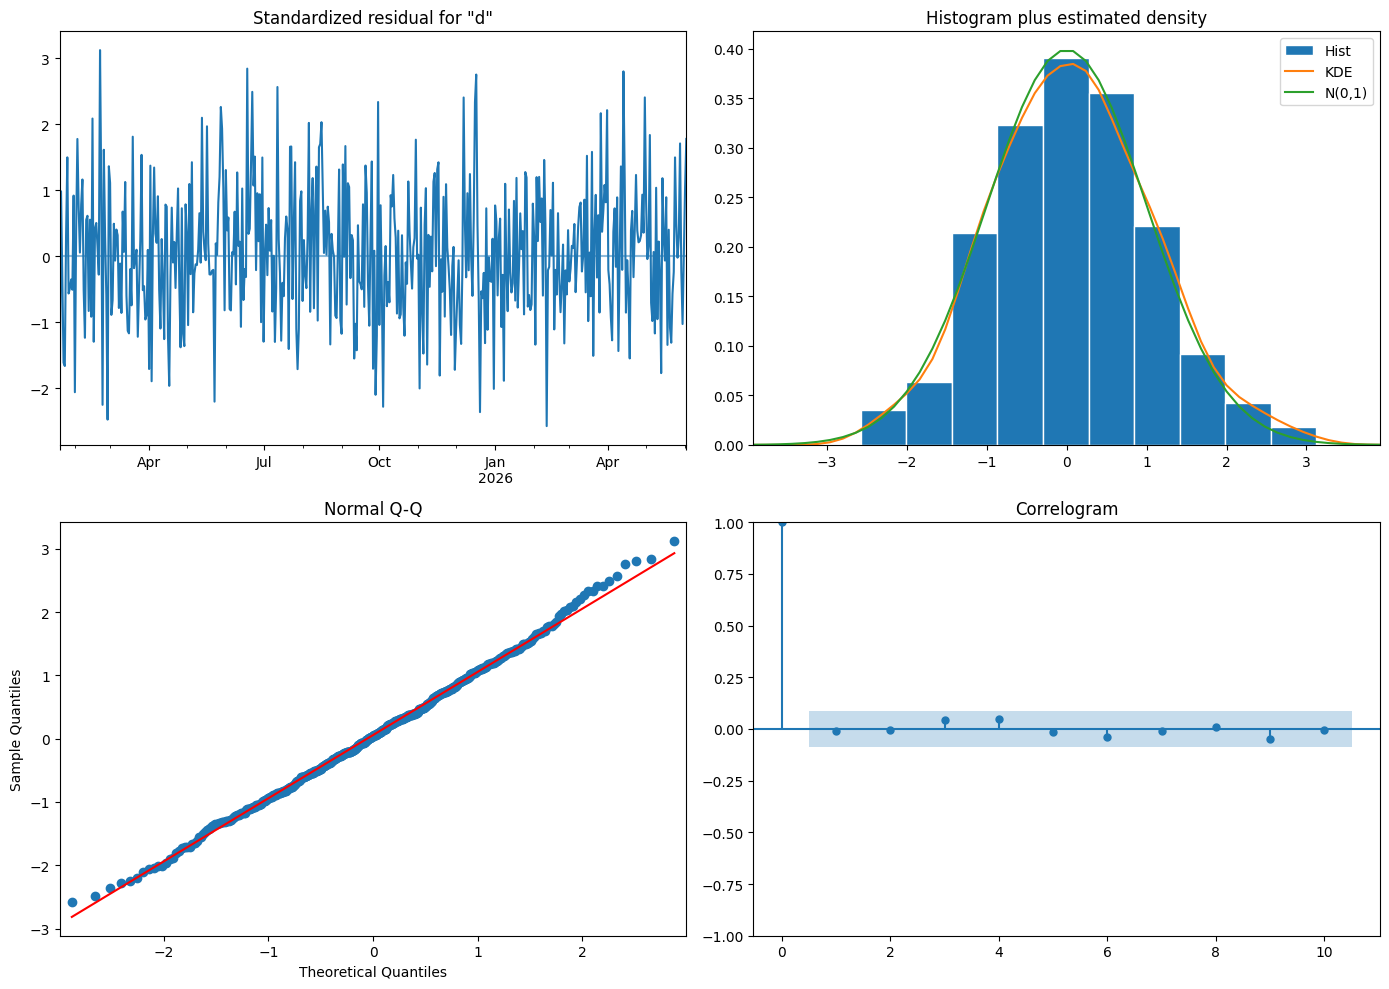

In [9]:
#full stats summary
print(best_model_results.summary())

#plot diagnostics to check the residuals (errors)
best_model_results.plot_diagnostics(figsize=(14, 10))
plt.tight_layout()
plt.show()

Next step is to forecast the model to 24 months into future, we will apply the best model which is ARIMA(1,1,3)

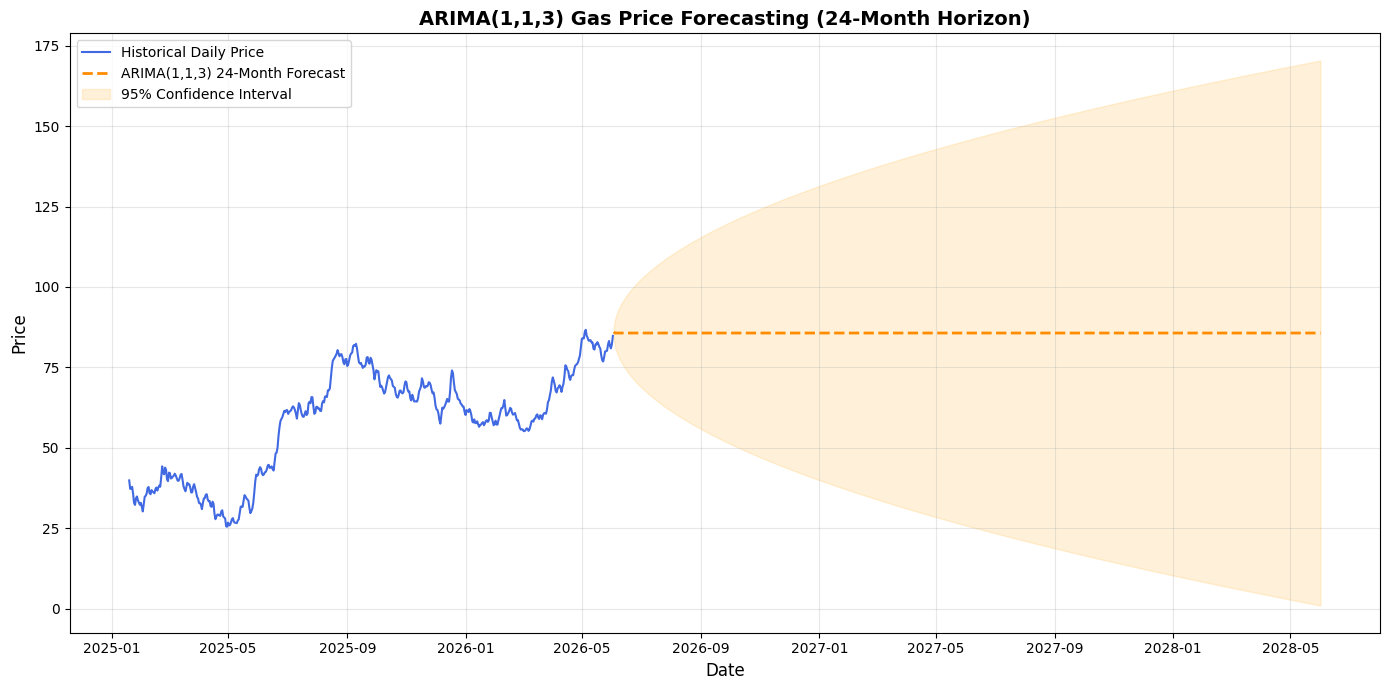

In [11]:
#forecast horizon = 24 months 365x2
forecast_steps = 730 

forecast_object = best_model_results.get_forecast(steps=forecast_steps)
forecast_mean = forecast_object.predicted_mean
confidence_intervals = forecast_object.conf_int()

#future daily date index after historical data ends
last_date = df.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps, freq='D')

forecast_mean.index = forecast_dates
confidence_intervals.index = forecast_dates

#historical data alongside the forecast
plt.figure(figsize=(14, 7))

# Plot the full historical data to give proper scale to the 2-year horizon
plt.plot(df.index, df['daily price'], label='Historical Daily Price', color='royalblue', linewidth=1.5)

# Plot the center line of the 24-month forecast
plt.plot(forecast_dates, forecast_mean, label='ARIMA(1,1,3) 24-Month Forecast', color='darkorange', linestyle='--', linewidth=2)

# Fill the 95% confidence interval (uncertainty zone)
plt.fill_between(forecast_dates, 
                 confidence_intervals.iloc[:, 0], 
                 confidence_intervals.iloc[:, 1], 
                 color='orange', alpha=0.15, label='95% Confidence Interval')

# Chart formatting
plt.title('ARIMA(1,1,3) Gas Price Forecasting (24-Month Horizon)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()